# Building a Data Pipeline 

### Imports

In [6]:
import numpy as np 
import pandas as pd 
import random
from randomtimestamp import randomtimestamp # type: ignore
from geopy.geocoders import Nominatim # type: ignore
from meteostat import Point, Daily # type: ignore
from datetime import datetime, timedelta
import time

import seaborn as sns 
import matplotlib.pyplot as plt 

from sklearn import preprocessing, svm 
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression 
from sklearn.preprocessing import OneHotEncoder


df_import = pd.read_csv("import_data/past_dummy_data.csv", delimiter=";")

### Data Cleaning

In [7]:
#wenn Spalte 'amount_used'leer ist, dann wird diese Zeile gelöscht (unbrauchbar)
df_import = df_import.dropna(subset=['amount_used'])

In [ ]:
#lösche Spalten, die leer sind
#df = df.drop('destination_sun', axis=1)
#df = df.drop('destination_tsun', axis=1)

In [69]:
#Zeilen mit mehr als 6 fehlenden Einträgen, werden gelöscht
# die zukunfts-daten haben alle min 6 leere werte
#df = df.dropna(thresh=df.shape[1] - 6)
#print(f"Anzahl der Zeilen nach der Löschung: {len(df)}")

Anzahl der Zeilen nach der Löschung: 50


# 1. Data Acquisition

In [ ]:
df_import.head(5)

,date,flight_number,departure,destination,travel_class,service,component,dish_type,region,passengers,...,destination_tavg,destination_tmin,destination_tmax,destination_prcp,destination_snow,destination_wdir,destination_wspd,destination_wpgt,destination_pres,destination_tsun
0,2024-01-16,4Y001,FRA,JFK,Business,First,Starter,Meat,North America,48,...,-2.1,-5.5,0.0,9.1,50.0,354,23.0,NaN,1011.6,NaN
1,2024-01-16,4Y001,FRA,JFK,Business,First,Starter,Veg,North America,48,...,-2.1,-5.5,0.0,9.1,50.0,354,23.0,NaN,1011.6,NaN
2,2024-01-16,4Y001,FRA,JFK,Business,First,Main,Meat,North America,48,...,-2.1,-5.5,0.0,9.1,50.0,354,23.0,NaN,1011.6,NaN
3,2024-01-16,4Y001,FRA,JFK,Business,First,Main,Veg,North America,48,...,-2.1,-5.5,0.0,9.1,50.0,354,23.0,NaN,1011.6,NaN
4,2024-01-16,4Y001,FRA,JFK,Business,First,Main,Fish,North America,48,...,-2.1,-5.5,0.0,9.1,50.0,354,23.0,NaN,1011.6,NaN


## 1.1 Add Geolocation

In [10]:
geolocator = Nominatim(user_agent="iata_locator")
def get_airport_coordinates(iata_code):
    time.sleep(0.1)
    location = geolocator.geocode(f"{iata_code} airport")
    if location:
        return {
            "latitude": location.latitude,
            "longitude": location.longitude,
        }
    else:
        return None
    

def create_df(cities):
    # requires an unique set of cities formatted as an array
    length = len(cities)
    coords = []
    for i in range(0, length):                
        coords.append(get_airport_coordinates(cities[i]))
        time.sleep(0.5)
            
    print(f"Anzahl der Städte: {len(coords)}")

    # DataFrame mit Koordinaten
    df_coords = pd.DataFrame({
        'city': cities,
        'latitude': [x['latitude'] for x in coords],
        'longitude': [x['longitude'] for x in coords]
    })
    return df_coords

departure_airports = set(df_import["departure"])
destination_airports = set(df_import["destination"])

all_airports = list(departure_airports.union(destination_airports))

df_airports = create_df(all_airports)

df_import['departure'] = df_import['departure'].astype(str)
df_import['destination'] = df_import['destination'].astype(str)
df_airports['city'] = df_airports['city'].astype(str)

df = df_import.merge(df_airports.rename(columns={
    'city': 'departure',
    'latitude': 'departure_latitude',
    'longitude': 'departure_longitude'
}), on='departure', how='left')

df = df.merge(df_airports.rename(columns={
    'city': 'destination',
    'latitude': 'destination_latitude',
    'longitude': 'destination_longitude'
}), on='destination', how='left')

df.head(10)


Anzahl der Städte: 13


,date,flight_number,departure,destination,travel_class,service,component,dish_type,region,passengers,...,potential_co2_savings,customer_satisfaction,departure_time,arrival_time,flight_duration,route,departure_latitude,departure_longitude,destination_latitude,destination_longitude
0,2024-01-16,4Y001,FRA,JFK,Business,First,Starter,Meat,North America,48,...,0,91,04:29,07:29,08:00,intercont,50.024413,8.5552,40.642948,-73.779373
1,2024-01-16,4Y001,FRA,JFK,Business,First,Starter,Veg,North America,48,...,"2,4",76,04:29,07:29,08:00,intercont,50.024413,8.5552,40.642948,-73.779373
2,2024-01-16,4Y001,FRA,JFK,Business,First,Main,Meat,North America,48,...,0,80,04:29,07:29,08:00,intercont,50.024413,8.5552,40.642948,-73.779373
3,2024-01-16,4Y001,FRA,JFK,Business,First,Main,Veg,North America,48,...,0,94,04:29,07:29,08:00,intercont,50.024413,8.5552,40.642948,-73.779373
4,2024-01-16,4Y001,FRA,JFK,Business,First,Main,Fish,North America,48,...,0,88,04:29,07:29,08:00,intercont,50.024413,8.5552,40.642948,-73.779373
5,2024-01-16,4Y001,FRA,JFK,Business,First,Dessert,Cheese,North America,48,...,0,69,04:29,07:29,08:00,intercont,50.024413,8.5552,40.642948,-73.779373
6,2024-01-16,4Y001,FRA,JFK,Business,First,Dessert,Sweet,North America,48,...,"5,6",77,04:29,07:29,08:00,intercont,50.024413,8.5552,40.642948,-73.779373
7,2024-01-16,4Y001,FRA,JFK,Business,Second,Breakfast,NaN,North America,48,...,0,96,04:29,07:29,08:00,intercont,50.024413,8.5552,40.642948,-73.779373
8,2024-01-16,4Y001,FRA,JFK,Business,Second,Dinner,Meat,North America,48,...,0,88,04:29,07:29,08:00,intercont,50.024413,8.5552,40.642948,-73.779373
9,2024-01-16,4Y001,FRA,JFK,Business,Second,Dinner,Veg,North America,48,...,0,88,04:29,07:29,08:00,intercont,50.024413,8.5552,40.642948,-73.779373


## 1.2 Add Weather Data

In [11]:
df.dtypes

date                        object
flight_number               object
departure                   object
destination                 object
travel_class                object
service                     object
component                   object
dish_type                   object
region                      object
passengers                   int64
amount_loaded                int64
amount_predicted_demand      int64
amount_used                  int64
amount_missed_order          int64
recommended_ratio           object
ratio                       object
load_factor                 object
price_per_dish              object
co2_per_item                object
items_saved                  int64
potential_cost_savings      object
potential_co2_savings       object
customer_satisfaction        int64
departure_time              object
arrival_time                object
flight_duration             object
route                       object
departure_latitude         float64
departure_longitude 

In [12]:
def get_weather(lat, lon, date):

    key = (lat, lon, date)
    today = datetime.today()

    date_no_string = datetime.strptime(date, '%Y-%m-%d')

    if today > date_no_string:
        today = today - timedelta(days=365)
    if key in weather_cache:
        return weather_cache[key]
    else:
        location = Point(lat, lon)

        start_date = end_date = datetime.strptime(date, '%Y-%m-%d')
        data = Daily(location, start_date, end_date).fetch()

        weather_columns = ['tavg', 'tmin', 'tmax', 'prcp', 'snow', 'wdir', 'wspd', 'wpgt', 'pres', 'tsun']

        if not data.empty:
            weather_data = {col: data[col].iloc[0] if col in data.columns else None for col in weather_columns}
        else:
            weather_data = {col: None for col in weather_columns}

        weather_cache[key] = weather_data
        time.sleep(0.1)
        return weather_data

weather_cache = {}
weather_results = []

for index, row in df.iterrows():
    try:
        departure_weather = get_weather(row['departure_latitude'], row['departure_longitude'], row['date'])
        
        departure_datetime = pd.to_datetime(row['date'] + ' ' + row['departure_time'])
        arrival_time = datetime.strptime(row['arrival_time'], "%H:%M").time()
        arrival_datetime = datetime.combine(departure_datetime.date(), arrival_time)

        if arrival_datetime < departure_datetime:
            arrival_datetime += timedelta(days=1)

        arrival_date = arrival_datetime.strftime("%Y-%m-%d")

        destination_weather = get_weather(row['destination_latitude'], row['destination_longitude'], arrival_date)

        combined_weather = {
            **{f"departure_{key}": value for key, value in departure_weather.items()},
            **{f"destination_{key}": value for key, value in destination_weather.items()}
        }
        weather_results.append(combined_weather)

    except Exception as e:
        print(f"Fehler in Zeile {index}: {e}")
        weather_results.append({col: None for col in combined_weather.keys()})

weather_df = pd.DataFrame(weather_results)
df = pd.concat([df, weather_df], axis=1)


KeyboardInterrupt: 

In [ ]:
# === Save Weather Data ===
df.to_csv('output/past_weather_data_output.csv', index=False)
df.to_excel('output/past_weather_data_output.xlsx', index=False)

In [13]:
df = pd.read_excel("output/past_weather_data_output.xlsx")

## 1.3 Add Country Data

In [14]:
country_cache = {}

country_results = []
def get_country(lat, lon):

    key = (lat, lon)
    
    if key in country_cache:
        return country_cache[key]
    else:
        try:
            location = geolocator.reverse((lat, lon), exactly_one=True, language="en")
            country = location.raw.get('address', {}).get('country', None)
            country_cache[key] = country
            time.sleep(0.3) 
            return country
        except Exception as e:
            print(f"Fehler beim Abrufen des Landes für {key}: {e}")
            return None
        
for index, row in df.iterrows():
    try: 
        departure_country = get_country(row['departure_latitude'], row['departure_longitude'])
        destination_country = get_country(row['destination_latitude'], row['destination_longitude'])
        
        combined_countries = {
            "departure_country": departure_country,
            "destination_country": destination_country
        }
    except:
        combined_countries = {
            "departure_country": None,
            "destination_country": None
        }
    
    country_results.append(combined_countries)

country_df = pd.DataFrame(country_results)
df = pd.concat([df, country_df], axis=1)

# ISO-Codes für Staaten
country_codes = pd.read_csv(r'import_data/country_codes.csv')
print (country_codes)
df['departure_country_code'] = ''
df['destination_country_code'] = ''
df = df.merge(country_codes, left_on='departure_country', right_on='Name', how='left')
df['departure_country_code'] = df['Code']
df = df.drop({'Name', 'Code'}, axis = 1)

df = df.merge(country_codes, left_on='destination_country', right_on='Name', how='left')
df['destination_country_code'] = df['Code']
df = df.drop({'Name', 'Code'}, axis = 1)


               Name Code
0       Afghanistan   AF
1           Albania   AL
2           Algeria   DZ
3    American Samoa   AS
4           Andorra   AD
..              ...  ...
244  Western Sahara   EH
245           Yemen   YE
246          Zambia   ZM
247        Zimbabwe   ZW
248   Åland Islands   AX

[249 rows x 2 columns]


## 1.4 Add GDP / Population 

In [15]:
#BIP für Staaten
import requests

gdp_cache = {}
population_cache = {}

df['departure_GDP_per_capita'] = ''
df['destination_GDP_per_capita'] = ''

def get_data_from_worldbank(country_code, indicator):
    """
    Holt Daten von der World Bank API für einen bestimmten Länder-Code und Indikator.
    """
    key = (country_code, indicator)

    if indicator == 'NY.GDP.MKTP.CD' and country_code in gdp_cache:
        return gdp_cache[country_code]
    if indicator == 'SP.POP.TOTL' and country_code in population_cache:
        return population_cache[country_code]
    
    try:
        url = f'http://api.worldbank.org/v2/country/{country_code}/indicator/{indicator}?format=json'
        response = requests.get(url)
        data = response.json()
        
        if response.status_code == 200 and len(data) > 1 and data[1]:
            value = data[1][0].get('value', None)
        else:
            value = None

        if indicator == 'NY.GDP.MKTP.CD':
            gdp_cache[country_code] = value
        elif indicator == 'SP.POP.TOTL':
            population_cache[country_code] = value

        time.sleep(0.1)
        return value
    except Exception as e:
        print(f"Fehler beim Abrufen von {indicator} für {country_code}: {e}")
        if indicator == 'NY.GDP.MKTP.CD':
            gdp_cache[country_code] = None
        elif indicator == 'SP.POP.TOTL':
            population_cache[country_code] = None
        return None

def calculate_gdp_per_capita(country_code):
    
    gdp = get_data_from_worldbank(country_code, 'NY.GDP.MKTP.CD')
    population = get_data_from_worldbank(country_code, 'SP.POP.TOTL')

    if gdp is not None and population is not None and population > 0:
        return gdp / population
    return None

for index, row in df.iterrows():
    try:
        df.at[index, 'departure_GDP_per_capita'] = calculate_gdp_per_capita(row['departure_country_code'])
        df.at[index, 'destination_GDP_per_capita'] = calculate_gdp_per_capita(row['destination_country_code'])
    except Exception as e:
        print(f"Fehler in Zeile {index}: {e}")

vegetarisch/vegan

In [16]:
# vegetarisch/vegan-Daten zu den Staaten
country_veg = pd.read_csv(r"import_data/vegetarisch_vegan.csv", sep = ';')

df['departure_country_veget_%'] = ''
df['departure_country_veget_no'] = ''
df['departure_country_veget_year'] = ''
df['departure_country_vegan_%'] = ''
df['departure_country_vegan_no'] = ''
df['departure_country_vegan_year'] = ''

df['destination_country_veget_%'] = ''
df['destination_country_veget_no'] = ''
df['destination_country_veget_year'] = ''
df['destination_country_vegan_%'] = ''
df['destination_country_vegan_no'] = ''
df['destination_country_vegan_year'] = ''

df = df.merge(country_veg, left_on='departure_country', right_on='Country', how='left')
df['departure_country_veget_%'] = df['Veget_in%']
df['departure_country_veget_no'] = df['Veget_no']
df['departure_country_veget_year'] = df['Veget_data_year']
df['departure_country_vegan_%'] = df['Vegan_in%']
df['departure_country_vegan_no'] = df['Vegan_no']
df['departure_country_vegan_year'] = df['Vegan_data_year']
df = df.drop({'Country', 'Veget_in%', 'Veget_no', 'Veget_data_year', 'Vegan_in%', 'Vegan_no', 'Vegan_data_year'}, axis = 1)

df = df.merge(country_veg, left_on='destination_country', right_on='Country', how='left')
df['destination_country_veget_%'] = df['Veget_in%']
df['destination_country_veget_no'] = df['Veget_no']
df['destination_country_veget_year'] = df['Veget_data_year']
df['destination_country_vegan_%'] = df['Vegan_in%']
df['destination_country_vegan_no'] = df['Vegan_no']
df['destination_country_vegan_year'] = df['Vegan_data_year']
df = df.drop({'Country', 'Veget_in%', 'Veget_no', 'Veget_data_year', 'Vegan_in%', 'Vegan_no', 'Vegan_data_year'}, axis = 1)

#Oktoberfest
#Weltmeisterschaft
#Europameisterschaft
#Olympische Spiele
#SuperBowl
#CopaAmerica
#Champions-League-Finale
#Wimbledon
#Coachella

In [17]:
def make_column(column_name):
    df[column_name] = ""

def to_bool(column):
    df[column] = df[column].astype('bool')

events = [
    'FIFA_WM_Herren',
    'FIFA_WM_Damen',
    'UEFA_EM_Herren',
    'UEFA_EM_Damen',
    'Champions-League_Herren',
    'Champions-League_Damen',
    'Olympische_Sommerspiele',
    'Olympische_Winterspiele',
    'Oktoberfest',
    'SuperBowl',
    'CopaAmerica',
    'GrandSlam_Tennis',
    'Coachella']

for event in events:
    make_column(event)
    to_bool(event)


#Funktion für 2 Tage früher und 2 später
from datetime import datetime, timedelta
def reisetage_erweitern_tupel(start_str, end_str):
    start_date = datetime.strptime(start_str, '%d.%m.%Y') - timedelta(days=2)  # Start 2 Tage früher
    end_date = datetime.strptime(end_str, '%d.%m.%Y') + timedelta(days=2)    # Ende 2 Tage später
    return (start_date, end_date)

def reisetage_erweitern_tripel(start_str, end_str, country):
    # Konvertiere die Start- und Enddaten und erweitere sie um 2 Tage
    start_date = datetime.strptime(start_str, '%d.%m.%Y') - timedelta(days=2)
    end_date = datetime.strptime(end_str, '%d.%m.%Y') + timedelta(days=2)
    return (start_date, end_date, country)



# FIFA-WM Herren
fifa_wm_herren_zeiträume = [
    ('11.06.2010', '11.07.2010', 'South Africa'),
    ('12.06.2014', '13.07.2014', 'Brazil'),
    ('14.06.2018', '15.07.2018', 'Russia'),
    ('20.11.2022', '18.12.2022', 'Qatar'),
    ('01.06.2026', '31.07.2026', 'Canada'),
    ('01.06.2026', '31.07.2026', 'Mexico'),
    ('01.06.2026', '31.07.2026', 'United States')]

fifa_wm_herren_zeiträume = [reisetage_erweitern_tripel(start, end, country) for start, end, country in fifa_wm_herren_zeiträume]

def is_fifa_wm_herren(date, departure, destination):
    for start, end, country in fifa_wm_herren_zeiträume:
         if (start <= date <= end) and (departure == country or destination == country):
            return True
    return False

df['FIFA_WM_Herren'] = df.apply(lambda row: is_fifa_wm_herren(pd.to_datetime(row['date']), row['departure_country'], row['destination_country']), axis=1)


# FIFA-WM Damen
fifa_wm_damen_zeiträume = [
    ('26.06.2011', '17.07.2011', 'Germany'),
    ('06.06.2015', '05.07.2015', 'Canada'),
    ('07.06.2019', '07.07.2019', 'France'),
    ('20.07.2023', '20.08.2023', 'Australia'),
    ('20.07.2023', '20.08.2023', 'New Zealand'),
    ('24.06.2027', '25.07.2027', 'Brazil')]

fifa_wm_damen_zeiträume = [reisetage_erweitern_tripel(start, end, country) for start, end, country in fifa_wm_damen_zeiträume]

def is_fifa_wm_damen(date, departure, destination):
    for start, end, country in fifa_wm_damen_zeiträume:
        if (start <= date <= end) and (departure == country or destination == country):
            return True
    return False

df['FIFA_WM_Damen'] = df.apply(lambda row: is_fifa_wm_damen(pd.to_datetime(row['date']), row['departure_country'], row['destination_country']), axis=1)



# Olympische Sommerspiele
olympische_sommerspiele_zeiträume = [
    ('25.07.2012', '12.08.2012', 'United Kingdom'),
    ('05.08.2016', '21.08.2016', 'Brazil'),
    ('23.07.2021', '08.08.2021', 'Japan'),
    ('26.07.2024', '11.08.2024', 'France'),
    ('14.07.2028', '30.07.2028', 'United States')]

olympische_sommerspiele_zeiträume_erweitert = [reisetage_erweitern_tripel(start, end, country) for start, end, country in olympische_sommerspiele_zeiträume]

def is_olympische_sommerspiele(date, departure, destination):
    for start, end, country in olympische_sommerspiele_zeiträume_erweitert:
        if (start <= date <= end) and (departure == country or destination == country):
            return True
    return False

df['Olympische_Sommerspiele'] = df.apply(lambda row: is_olympische_sommerspiele(pd.to_datetime(row['date']), row['departure_country'], row['destination_country']), axis=1)



#Olympische Winterspiele
olympische_winterspiele_zeiträume = [
    ('12.02.2010', '28.02.2010', 'Canada'),
    ('07.02.2014', '23.02.2014', 'Russia'),
    ('09.02.2018', '25.02.2018', 'South Korea'),
    ('04.02.2022', '20.02.2022', 'China'),
    ('06.02.2026', '22.02.2026', 'Italy')]

olympische_winterspiele_zeiträume_erweitert = [reisetage_erweitern_tripel(start, end, country) for start, end, country in olympische_winterspiele_zeiträume]

def is_olympische_winterspiele(date, departure, destination):
    for start, end, country in olympische_winterspiele_zeiträume_erweitert:
        if (start <= date <= end) and (departure == country or destination == country):
            return True
    return False

df['Olympische_Winterspiele'] = df.apply(lambda row: is_olympische_winterspiele(pd.to_datetime(row['date']), row['departure_country'], row['destination_country']), axis=1)



# UEFA EM Herren
uefa_em_herren_zeiträume = [
    ('07.06.2008', '29.06.2008', 'Austria'),
    ('07.06.2008', '29.06.2008', 'Switzerland'),
    ('08.06.2012', '01.07.2012', 'Poland'),
    ('08.06.2012', '01.07.2012', 'Ukraine'),    
    ('10.06.2016', '10.07.2016', 'France'),
    ('11.06.2020', '11.07.2020', 'Europe'),
    ('14.06.2024', '14.07.2024', 'Germany'),
    ('08.06.2028', '08.07.2028', 'United Kingdom')]

uefa_em_herren_zeiträume_erweitert = [reisetage_erweitern_tripel(start, end, country) for start, end, country in uefa_em_herren_zeiträume]

def is_uefa_em_herren(date, departure, destination):
    for start, end, country in uefa_em_herren_zeiträume_erweitert:
        if (start <= date <= end) and (departure == country or destination == country):
            return True
    return False
    
df['UEFA_EM_Herren'] = df.apply(lambda row: is_olympische_winterspiele(pd.to_datetime(row['date']), row['departure_country'], row['destination_country']), axis=1)



#UEFA EM Damen
uefa_em_damen_zeiträume = [
    ('23.08.2009', '01.09.2009', 'Finland'),
    ('05.07.2013', '28.07.2013', 'Sweden'),
    ('06.07.2017', '06.08.2017', 'Netherlands'),
    ('16.07.2022', '31.07.2022', 'England'),
    ('10.07.2025', '26.07.2025', 'Sweden'),
    ('01.07.2029', '21.07.2029', 'Switzerland')]

uefa_em_damen_zeiträume_erweitert = [reisetage_erweitern_tripel(start, end, country) for start, end, country in uefa_em_damen_zeiträume]

def is_uefa_em_damen(date, departure, destination):
    for start, end, country in uefa_em_damen_zeiträume_erweitert:
        if (start <= date <= end) and (departure == country or destination == country):
            return True
    return False

df['UEFA_EM_Damen'] = df.apply(lambda row: is_uefa_em_damen(pd.to_datetime(row['date']), row['departure_country'], row['destination_country']), axis=1)



# Champions-League-Finale Herren
champions_herren_zeiten = [
    ('22.05.2010', 'Spain'),
    ('28.05.2011', 'United Kingdom'),
    ('19.05.2012', 'Germany'),
    ('25.05.2013', 'United Kingdom'),
    ('24.05.2014', 'Portugal'),
    ('06.06.2015', 'Germany'),
    ('28.05.2016', 'Italy'),
    ('03.06.2017', 'Wales'),
    ('26.05.2018', 'Ukraine'),
    ('01.06.2019', 'Spain'),
    ('23.08.2020', 'Portugal'),
    ('29.05.2021', 'Portugal'),
    ('28.05.2022', 'France'),
    ('10.06.2023', 'Turkey'),
    ('01.06.2024', 'United Kingdom'),
    ('31.05.2025', 'Germany'),
    ('30.05.2026', 'Italy')]

champions_herren_zeiträume_erweitert = [reisetage_erweitern_tripel(date, date, country) for date, country in champions_herren_zeiten]

def is_champions_herren(row):
    date = pd.to_datetime(row['date'])
    departure = row['departure_country']
    destination = row['destination_country']
    for (start, end, country,) in champions_herren_zeiträume_erweitert:
        if (start <= date <= end) and (departure == country or destination == country):
            return True
    return False

df['Champions-League_Herren'] = df.apply(is_champions_herren, axis=1)



# Champions-League-Finale Damen
champions_damen_zeiten = [
    ('20.05.2010', 'Spain'),
    ('26.05.2011', 'United Kingdom'),
    ('17.05.2012', 'Germany'),
    ('23.05.2013', 'United Kingdom'),
    ('22.05.2014', 'Portugal'),
    ('14.05.2015', 'Germany'),
    ('26.05.2016', 'Italy'),
    ('01.06.2017', 'Wales'),
    ('24.05.2018', 'Ukraine'),
    ('18.05.2019', 'Hungary'),
    ('30.08.2020', 'Spain'),
    ('16.05.2021', 'Sweden'),
    ('21.05.2022', 'Italy'),
    ('03.06.2023', 'Netherlands'),
    ('24.05.2024', 'Spain'),
    ('24.05.2025', 'Portugal'),
    ('22.05.2026', 'Norway')]

champions_damen_zeiträume_erweitert = [reisetage_erweitern_tripel(date, date, country) for date, country in champions_damen_zeiten]

def is_champions_damen(row):
    date = pd.to_datetime(row['date'])
    departure = row['departure_country']
    destination = row['destination_country']
    for (start, end, country) in champions_damen_zeiträume_erweitert:
        if (start <= date <= end) and (departure == country or destination == country):
            return True
    return False

df['Champions-League_Damen'] = df.apply(is_champions_damen, axis=1)


# Super Bowl
super_bowl_zeiten = [
    '07.02.2010',
    '06.02.2011',
    '05.02.2012',
    '03.02.2013',
    '02.02.2014',
    '01.02.2015',
    '07.02.2016',
    '05.02.2017',
    '04.02.2018',
    '03.02.2019',
    '02.02.2020',
    '07.02.2021',
    '13.02.2022',
    '12.02.2023',
    '11.02.2024',
    '09.02.2025',
    '08.02.2026']

super_bowl_zeiten = [reisetage_erweitern_tupel(date, date) for date in super_bowl_zeiten]

def is_super_bowl(date, departure, destination):
    if departure == 'United States' or destination == 'United States':
        for start, end in super_bowl_zeiten:
            if start <= date <= end:
                return True
    return False

df['SuperBowl'] = df.apply(lambda row: is_super_bowl(pd.to_datetime(row['date']), row['departure_country'], row['destination_country']), axis=1)



# Coachella
coachella_zeiten = [
    ('16.04.2010', '18.04.2010'), ('23.04.2010', '25.04.2010'),
    ('15.04.2011', '17.04.2011'), ('22.04.2011', '24.04.2011'),
    ('13.04.2012', '15.04.2012'), ('20.04.2012', '22.04.2012'),
    ('12.04.2013', '14.04.2013'), ('19.04.2013', '21.04.2013'),
    ('11.04.2014', '13.04.2014'), ('18.04.2014', '20.04.2014'),
    ('10.04.2015', '12.04.2015'), ('17.04.2015', '19.04.2015'),
    ('15.04.2016', '17.04.2016'), ('22.04.2016', '24.04.2016'),
    ('14.04.2017', '16.04.2017'), ('21.04.2017', '23.04.2017'),
    ('13.04.2018', '15.04.2018'), ('20.04.2018', '22.04.2018'),
    ('12.04.2019', '14.04.2019'), ('19.04.2019', '21.04.2019'),
    ('15.04.2022', '17.04.2022'), ('22.04.2022', '24.04.2022'),
    ('14.04.2023', '16.04.2023'), ('21.04.2023', '23.04.2023'),
    ('12.04.2024', '14.04.2024'), ('19.04.2024', '21.04.2024'),
    ('11.04.2025', '13.04.2025'), ('18.04.2025', '20.04.2025'),
    ('10.04.2026', '12.04.2026'), ('17.04.2026', '19.04.2026')]

coachella_zeiten = [reisetage_erweitern_tupel(start, end) for start, end in coachella_zeiten]

def is_coachella(date, departure, destination):
    if departure == 'United States' or destination == 'United States':
        for start, end in coachella_zeiten:
            if start <= date <= end:
                return True
    return False

df['Coachella'] = df.apply(lambda row: is_coachella(pd.to_datetime(row['date']), row['departure_country'], row['destination_country']), axis=1)


# Oktoberfest
oktoberfest_zeiten = [
    ('18.09.2010', '03.10.2010'),
    ('17.09.2011', '03.10.2011'),
    ('22.09.2012', '07.10.2012'),
    ('21.09.2013', '06.10.2013'),
    ('20.09.2014', '05.10.2014'),
    ('19.09.2015', '04.10.2015'),
    ('17.09.2016', '03.10.2016'),
    ('16.09.2017', '03.10.2017'),
    ('22.09.2018', '07.10.2018'),
    ('21.09.2019', '06.10.2019'),
    ('17.09.2022', '03.10.2022'),
    ('16.09.2023', '03.10.2023'),
    ('21.09.2024', '06.10.2024'),
    ('20.09.2025', '05.10.2025'),
    ('19.09.2026', '04.10.2026')]

oktoberfest_zeiten = [reisetage_erweitern_tupel(start, end) for start, end in oktoberfest_zeiten]

def is_oktoberfest(date, departure, destination):
    if departure == 'Germany' or destination == 'Germany':
        for start, end in oktoberfest_zeiten:
            if start <= date <= end:
                return True
    return False

df['Oktoberfest'] = df.apply(lambda row: is_oktoberfest(pd.to_datetime(row['date']), row['departure_country'], row['destination_country']), axis=1)


# Copa América
copa_america_zeiten = [
    ('01.07.2011', '24.07.2011', 'Argentina'),
    ('11.06.2015', '04.07.2015', 'Chile'),
    ('03.06.2016', '26.06.2016', 'United States'),
    ('14.06.2019', '07.07.2019', 'Brazil'),
    ('13.06.2021', '10.07.2021', 'Brazil'),
    ('20.06.2024', '14.07.2024', 'United States'),
    ('01.06.2028', '15.06.2028', 'United States')]

copa_america_zeiten_erweitert = [reisetage_erweitern_tripel(start, end, country) for start, end, country in copa_america_zeiten]

def is_copa_america(row):
    date = pd.to_datetime(row['date'])
    departure = row['departure_country']
    destination = row['destination_country']
    for (start, end, country) in copa_america_zeiten_erweitert:
        if (start <= date <= end) and (departure == country or destination == country):
            return True
    return False

df['Copa_America'] = df.apply(is_copa_america, axis=1)


# Grand Slams Tennis
grand_slam_zeiten = [
    # Australian Open (Australien)
    ('18.01.2010', '31.01.2010', 'Australia'), ('17.01.2011', '30.01.2011', 'Australia'),
    ('16.01.2012', '29.01.2012', 'Australia'), ('14.01.2013', '27.01.2013', 'Australia'),
    ('13.01.2014', '26.01.2014', 'Australia'), ('19.01.2015', '01.02.2015', 'Australia'),
    ('18.01.2016', '31.01.2016', 'Australia'), ('16.01.2017', '29.01.2017', 'Australia'),
    ('15.01.2018', '28.01.2018', 'Australia'), ('14.01.2019', '27.01.2019', 'Australia'),
    ('20.01.2020', '02.02.2020', 'Australia'), ('08.02.2021', '21.02.2021', 'Australia'),
    ('17.01.2022', '30.01.2022', 'Australia'), ('16.01.2023', '29.01.2023', 'Australia'),
    ('15.01.2024', '28.01.2024', 'Australia'),
    
    # French Open (Frankreich)
    ('23.05.2010', '06.06.2010', 'France'), ('22.05.2011', '05.06.2011', 'France'),
    ('27.05.2012', '10.06.2012', 'France'), ('26.05.2013', '09.06.2013', 'France'),
    ('25.05.2014', '08.06.2014', 'France'), ('24.05.2015', '07.06.2015', 'France'),
    ('22.05.2016', '05.06.2016', 'France'), ('28.05.2017', '11.06.2017', 'France'),
    ('27.05.2018', '10.06.2018', 'France'), ('26.05.2019', '09.06.2019', 'France'),
    ('27.09.2020', '11.10.2020', 'France'), ('30.05.2021', '13.06.2021', 'France'),
    ('22.05.2022', '05.06.2022', 'France'), ('28.05.2023', '11.06.2023', 'France'),
    ('26.05.2024', '09.06.2024', 'France'),

    # Wimbledon (Vereinigtes Königreich)
    ('21.06.2010', '04.07.2010', 'United Kingdom'), ('20.06.2011', '03.07.2011', 'United Kingdom'),
    ('25.06.2012', '08.07.2012', 'United Kingdom'), ('24.06.2013', '07.07.2013', 'United Kingdom'),
    ('23.06.2014', '06.07.2014', 'United Kingdom'), ('29.06.2015', '12.07.2015', 'United Kingdom'),
    ('27.06.2016', '10.07.2016', 'United Kingdom'), ('03.07.2017', '16.07.2017', 'United Kingdom'),
    ('02.07.2018', '15.07.2018', 'United Kingdom'), ('01.07.2019', '14.07.2019', 'United Kingdom'),
    ('28.06.2021', '11.07.2021', 'United Kingdom'), ('27.06.2022', '10.07.2022', 'United Kingdom'),
    ('03.07.2023', '16.07.2023', 'United Kingdom'), ('24.06.2024', '07.07.2024', 'United Kingdom'),

    # US Open (Vereinigte Staaten)
    ('30.08.2010', '12.09.2010', 'United States'), ('29.08.2011', '11.09.2011', 'United States'),
    ('27.08.2012', '09.09.2012', 'United States'), ('26.08.2013', '08.09.2013', 'United States'),
    ('25.08.2014', '07.09.2014', 'United States'), ('31.08.2015', '13.09.2015', 'United States'),
    ('29.08.2016', '11.09.2016', 'United States'), ('28.08.2017', '10.09.2017', 'United States'),
    ('27.08.2018', '09.09.2018', 'United States'), ('26.08.2019', '08.09.2019', 'United States'),
    ('31.08.2020', '13.09.2020', 'United States'), ('30.08.2021', '12.09.2021', 'United States'),
    ('29.08.2022', '11.09.2022', 'United States'), ('28.08.2023', '10.09.2023', 'United States'),
    ('26.08.2024', '08.09.2024', 'United States')]

grand_slam_zeiten = [reisetage_erweitern_tripel(start, end, country) for start, end, country in grand_slam_zeiten]

def is_grand_slam(row):
    date = pd.to_datetime(row['date'])
    departure = row['departure_country']
    destination = row['destination_country']
    for (start, end, country) in grand_slam_zeiten:
        if (start <= date <= end) and (departure == country or destination == country):
            return True
    return False

df['GrandSlam'] = df.apply(is_grand_slam, axis=1)

In [18]:
df.to_excel('output/past_pre_processing.xlsx', index=False)

In [21]:
df = pd.read_excel("output/past_pre_processing.xlsx")

## 1.5 World-wide public Holidays

In [8]:
def get_public_holidays(year, country_code, holiday_cache):
    if (year, country_code) in holiday_cache:
        return holiday_cache[(year, country_code)]
    
    url = f"https://date.nager.at/api/v3/PublicHolidays/{year}/{country_code}"
    try:
        response = requests.get(url)
        if response.status_code == 200:
            holidays = response.json()
            holiday_dates = {holiday["date"] for holiday in holidays}
            holiday_cache[(year, country_code)] = holiday_dates
            time.sleep(0.1)
            return holiday_dates
        else:
            print(f"Fehler bei der Anfrage für {country_code}: {response.status_code}")
            holiday_cache[(year, country_code)] = set()
            return set()
    except Exception as e:
        print(f"Fehler beim Abrufen der Daten für {country_code}: {e}")
        holiday_cache[(year, country_code)] = set()
        return set()

def add_holiday_columns(df):
    holiday_cache = {}
    years = []
    for date in df['date']:
        year = pd.to_datetime(date, format='%Y-%m-%d').year
        years.append(year)
        
    country_codes = set(df["departure_country_code"].dropna()).union(set(df["destination_country_code"].dropna()))
    
    for year in years:
        for country_code in country_codes:
            get_public_holidays(year, country_code, holiday_cache)
    
    df["departure_holiday"] = False
    df["destination_holiday"] = False
    
    for index, row in df.iterrows():
        if index > 50:
            break
        year = row["date"][:4]
        departure_code = row["departure_country_code"]
        destination_code = row["destination_country_code"]
        date = row["date"]
        
        if pd.notna(departure_code):
            df.at[index, "departure_holiday"] = date in holiday_cache.get((year, departure_code), set())
        
        if pd.notna(destination_code):
            df.at[index, "destination_holiday"] = date in holiday_cache.get((year, destination_code), set())
    
    return df


df = add_holiday_columns(df)

## ML Preprocessing

In [161]:
#Entfernung zwischen Departure und Destination
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    return R * c

df["distance_km"] = df.apply(
    lambda row: haversine(row["departure_latitude"], row["departure_longitude"], row["destination_latitude"], row["destination_longitude"]), axis=1)

In [165]:
#Kategorien für Tageszeiten
def daytime_category(stunde):
    if 6 <= stunde < 11:
        return 1
    elif 11 <= stunde < 15:
        return 2
    elif 15 <= stunde < 18:
        return 3
    elif 18 <= stunde < 22:
        return 4
    else:
        return 5

df["departure_daytime"] = pd.to_datetime(df["departure_time"], format="%H:%M").dt.hour.apply(daytime_category)
df["arrival_daytime"] = pd.to_datetime(df["arrival_time"], format="%H:%M").dt.hour.apply(daytime_category)

ValueError: time data "4" doesn't match format "%H:%M", at position 0. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [164]:
#datetime-Felder entfernen für Modell-Training
def to_date(column):
    df[column] = pd.to_datetime(df[column], format='%Y-%m-%d')

def to_time(column):
    df[column] = pd.to_datetime(df[column], format='%H:%M')

to_date('date')
to_time('departure_time')
to_time('arrival_time')
to_time('flight_duration')

df['date'] = pd.to_datetime(df['date'])
df['date'] = df['date'].astype('int64') // 10**9  # Epoch-Zeit in Sekunden
df['departure_time'] = df['departure_time'].dt.hour
df['arrival_time'] = df['arrival_time'].dt.hour
df['flight_duration'] = df['flight_duration'].dt.hour

text_felder = ['recommended_ratio', 'ratio', 'load_factor', 'price_per_dish', 'co2_per_item', 'potential_cost_savings', 'potential_co2_savings', 'departure_GDP_per_capita', 'destination_GDP_per_capita']
for feld in text_felder:
    df[feld] = df[feld].replace(',', '.', regex=True).astype(float)
print(df.dtypes)

date                                int64
flight_number                      object
departure                          object
destination                        object
travel_class                       object
service                            object
component                          object
dish_type                          object
region                             object
passengers                          int64
amount_loaded                       int64
amount_predicted_demand             int64
amount_used                         int64
amount_missed_order                 int64
recommended_ratio                 float64
ratio                             float64
load_factor                       float64
price_per_dish                    float64
co2_per_item                      float64
items_saved                         int64
potential_cost_savings            float64
potential_co2_savings             float64
customer_satisfaction               int64
departure_time                    

In [166]:
#die Country_codes werden nicht gebraucht
df = df.drop(['departure_country_code', 'destination_country_code'], axis=1)

In [167]:
#alle leeren Felder zu NaN machen
df.replace("", float('NaN'), inplace=True)

In [168]:
#df.fillna({'dish_type': 'Breakfast'}, inplace=True)

In [169]:
#wie oft 1 oder 2 oder 3 usw. NaN-Werte pro Zeile
nan_counts_per_row = df.isna().sum(axis=1)
nan_distribution = nan_counts_per_row.value_counts().sort_index()
print("Anzahl der Zeilen mit einer bestimmten Anzahl an NaN-Werten:")
print(nan_distribution)

Anzahl der Zeilen mit einer bestimmten Anzahl an NaN-Werten:
1      708
2     8486
3    18758
4      288
5      230
Name: count, dtype: int64


In [ ]:
#Zeilen mit mehr als 3 fehlenden Einträgen, werden gelöscht
#df = df.dropna(thresh=df.shape[1] - 3)

In [174]:
# Berechne die Anzahl der NaN-Werte in jeder Spalte
nan_counts_per_column = df.isna().sum()
rows_with_nan = nan_counts_per_column[nan_counts_per_column > 0]
print("Spalten mit mindestens einem NaN-Wert und deren Anzahl:")
print(rows_with_nan)
print(f"Anzahl der Zeilen: {df.shape[0]}")

count = df[df['destination_snow'] > 0].shape[0]
print(f"Anzahl der Zeilen, bei denen destination_snow > 0 ist: {count}")

Spalten mit mindestens einem NaN-Wert und deren Anzahl:
Series([], dtype: int64)
Anzahl der Zeilen: 28470
Anzahl der Zeilen, bei denen destination_snow > 0 ist: 135


In [171]:
#Spalten mit überwiegend NaN-Werten behandeln
df.fillna({'destination_snow': 0 }, inplace=True)
df = df.drop(['destination_wpgt', 'destination_tsun'], axis=1)

In [173]:
#Felder mit NaN-Werten werden durch Median der Spalte ersetzt
columns_with_nan = df.columns[df.isna().any()]
print("Spalten mit mindestens einem NaN-Wert:")
print(columns_with_nan)

medians = {col: df[col].median() for col in columns_with_nan}
for col in columns_with_nan:
    df[col] = df[col].fillna(medians[col])

Spalten mit mindestens einem NaN-Wert:
Index(['departure_snow', 'departure_tsun', 'destination_prcp',
       'destination_pres'],
      dtype='object')


In [175]:
#Kategorien für Wetter
def temp_category(temp):
    if temp < 0:
        return 1
    elif 0 <= temp < 10:
        return 2
    elif 10 <= temp < 20:
        return 3
    elif 20 <= temp < 30:
        return 4
    else:
        return 5

df['departure_temperature_category'] = df['departure_tavg'].apply(temp_category)
df['arrival_temperature_category'] = df['destination_tavg'].apply(temp_category)

def prcp_category(prcp):
    if prcp == 0:
        return 1
    elif 0 < prcp < 2.5:
        return 2
    elif 2.5 <= prcp < 7.6:
        return 3
    elif 7.6 <= prcp:
        return 4

df['departure_rain_category'] = df["departure_prcp"].apply(prcp_category)
df['arrival_rain_category'] = df["destination_prcp"].apply(prcp_category)

In [176]:
int_felder = ['departure_daytime', 'arrival_daytime', 'departure_temperature_category',
              'arrival_temperature_category', 'departure_rain_category', 'arrival_rain_category']
for int in int_felder:
    df[int].astype('int32')

In [179]:
non_int_float_columns = [col for col in df.columns if df[col].dtypes not in ['int32', 'int64', 'float64', 'bool']]

# Drucke die Spaltennamen
print(non_int_float_columns)
for x in non_int_float_columns:
    print(df[x].dtypes)

[]


In [178]:
#one-hot-encoding: jede Kategorie kriegt eine bool-Spalte
df = pd.get_dummies(df, non_int_float_columns)

In [180]:
df.to_excel('output/past_pre_model.xlsx', index=False)

In [22]:
import pandas as pd
df = pd.read_excel('output/past_pre_model.xlsx')


60
8


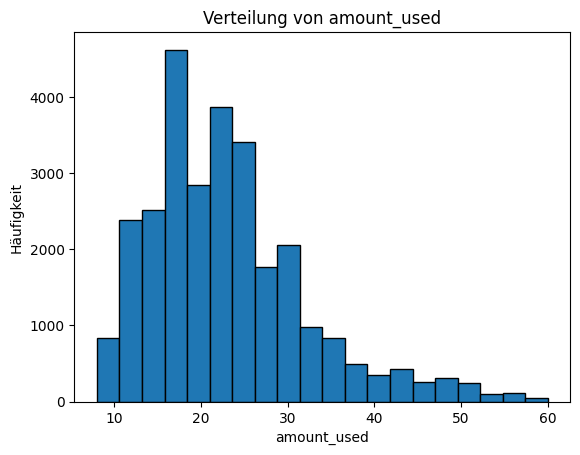

In [5]:
print(df['amount_used'].max())
print(df['amount_used'].min())
import matplotlib.pyplot as plt
plt.hist(df['amount_used'], bins=20, edgecolor='k')
plt.title('Verteilung von amount_used')
plt.xlabel('amount_used')
plt.ylabel('Häufigkeit')
plt.show()

Modell training

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

data = pd.read_excel('output/past_pre_model.xlsx')

X = data.drop(columns=['amount_used', 'amount_predicted_demand'])
y = data['amount_used', 'amount_predicted_demand']

# 3. Daten aufteilen
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Decision Tree Modell trainieren
model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)

# 5. Modell evaluieren
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred)

print(f'MAE: {mae}')
print(f'RMSE: {rmse}')

# 6. Prognose auf neuen Daten
data_new = pd.read_excel('output/future_pre_model.xlsx')  # Neue geplante Flüge
X_new = data_new.reindex(columns=X.columns, fill_value=0)

predictions = model.predict(X_new)

# Ergebnisse in die Tabelle schreiben
data_new['amount_used'] = predictions
data_new.to_csv('output/flugdaten_mit_prognosen.csv', index=False)

MAE: 0.3025992272567615
RMSE: 0.36933614330874603


In [7]:
feature_importances = pd.Series(model.feature_importances_, index=X.columns)
print(feature_importances.sort_values(ascending=False))

amount_predicted_demand      0.990264
amount_loaded                0.003211
items_saved                  0.003087
recommended_ratio            0.000535
potential_cost_savings       0.000372
                               ...   
destination_AMS              0.000000
destination_ZRH              0.000000
component_Main               0.000000
travel_class_Business        0.000000
departure_country_Germany    0.000000
Length: 132, dtype: float64


In [6]:
data_new.to_excel('output/prognose.xlsx', index=False)

In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# 1. Daten einlesen
data = pd.read_excel('output/past_pre_model.xlsx')

# 2. Features und Zielvariable definieren
X = data.drop(columns=['amount_used'])
y = data['amount_used']

# 3. Daten aufteilen in Trainings- und Testdaten
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. RandomForest Modell trainieren
model = RandomForestRegressor(random_state=42, n_estimators=100, max_depth=10, min_samples_split=10, min_samples_leaf=5)
model.fit(X_train, y_train)

# 5. Modell evaluieren
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'MAE: {mae}')
print(f'RMSE: {rmse}')

# 6. Prognose auf neuen Daten
data_new = pd.read_excel('output/future_pre_model.xlsx')  # Neue geplante Flüge
X_new = data_new.reindex(columns=X.columns, fill_value=0)  # Sicherstellen, dass alle Spalten übereinstimmen

# Vorhersage machen
predictions = model.predict(X_new)

# Ergebnisse in die Tabelle schreiben
data_new['amount_used'] = predictions
data_new.to_csv('output/prognose2.csv', index=False)


MAE: 0.2838574235516201
RMSE: 0.4426531321316285


In [8]:
data_new.to_excel('output/prognose2.xlsx', index=False)

In [25]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# 1. Daten laden
data = pd.read_excel('output/past_pre_model.xlsx')

# 2. Features und Zielvariablen definieren
X = data.drop(columns=['amount_used', 'amount_predicted_demand', 'amount_loaded', 'recommended_ratio', 'amount_missed_order', 'items_saved', 'potential_cost_savings', 'potential_co2_savings', 'customer_satisfaction'])
y = data[['amount_used', 'amount_predicted_demand', 'amount_loaded', 'recommended_ratio', 'customer_satisfaction', 'amount_missed_order']]  # Beide Zielvariablen

# 3. Daten aufteilen
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Multitask-Modell mit MultiOutputRegressor trainieren
base_model = DecisionTreeRegressor(random_state=42)
model = MultiOutputRegressor(base_model)
model.fit(X_train, y_train)

# 5. Modell evaluieren
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'MAE: {mae}')
print(f'RMSE: {rmse}')

# 6. Prognose auf neuen Daten
data_new = pd.read_excel('output/future_pre_model.xlsx')  # Neue geplante Flüge
X_new = data_new.reindex(columns=X.columns, fill_value=0)

predictions = model.predict(X_new)

# Ergebnisse in die Tabelle schreiben
data_new['amount_used'] = predictions[:, 0]  # First target variable
data_new['amount_predicted_demand'] = predictions[:, 1]  # Second target variable
data_new['amount_loaded'] = predictions[:, 2]  # Third target variable
data_new['recommended_ratio'] = predictions[:, 3]  # Third target variable
data_new['customer_satisfaction'] = predictions[:, 3]  # Third target variable
data_new['amount_missed_order'] = predictions[:, 3]  # Third target variable

prognose = pd.read_excel('output/prognose.xlsx')
prognose['amount used'] = ''
prognose['amount_predicted_demand'] = ''
prognose['amount_loaded'] = ''
prognose['recommended_ratio'] = ''
prognose['customer_satisfaction'] = ''
prognose['amount_missed_order'] = ''

prognose['amount used'] = data_new['amount_used']
prognose['amount_predicted_demand'] = data_new['amount_predicted_demand']
prognose['amount_loaded'] = data_new['amount_loaded']
prognose['recommended_ratio'] = data_new['recommended_ratio']
prognose['customer_satisfaction'] = data_new['customer_satisfaction']
prognose['amount_missed_order'] = data_new['amount_missed_order']


prognose.to_excel('output/prognose.xlsx', index=False)

MAE: 3.2831723451586465
RMSE: 6.6939958413729235


In [24]:
importances_used = model.estimators_[0].feature_importances_
importances_predicted_demand = model.estimators_[1].feature_importances_

# Feature-Importanz für 'amount_used' sortiert ausgeben
feature_importance_used = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances_used
})
feature_importance_used = feature_importance_used.sort_values(by='Importance', ascending=False)

print("\nFeature Importances for 'amount_used' (sorted):")
print(feature_importance_used)

# Feature-Importanz für 'amount_predicted_demand' sortiert ausgeben
feature_importance_predicted_demand = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances_predicted_demand
})
feature_importance_predicted_demand = feature_importance_predicted_demand.sort_values(by='Importance', ascending=False)

print("\nFeature Importances for 'amount_predicted_demand' (sorted):")
print(feature_importance_predicted_demand)


Feature Importances for 'amount_used' (sorted):
                       Feature  Importance
101        dish_type_Breakfast    0.494431
1                   passengers    0.286045
2                        ratio    0.080695
99              component_Main    0.039165
28            destination_wdir    0.005299
..                         ...         ...
31    departure_GDP_per_capita    0.000000
79               departure_FRA    0.000000
92       travel_class_Business    0.000000
95         component_Breakfast    0.000000
113  departure_country_Germany    0.000000

[124 rows x 2 columns]

Feature Importances for 'amount_predicted_demand' (sorted):
                       Feature  Importance
101        dish_type_Breakfast    0.484386
1                   passengers    0.284571
2                        ratio    0.080153
99              component_Main    0.041216
28            destination_wdir    0.005249
..                         ...         ...
31    departure_GDP_per_capita    0.000000
79    